# 07 — Bias Validation
**Fingo Income Predictor** | Tim CC26-PSU217

Input:
- `data/processed/income_features.csv`
- `data/processed/survey_temporal_mapped.csv`
- `data/synthetic/synthetic_52week_user_income.csv`

Output:
- `outputs/reports/bias_validation_report.md`
- Charts ke `outputs/charts/`

Notebook ini memvalidasi apakah data synthetic masih masuk akal terhadap survey dan benchmark BPS, termasuk distribusi, seasonal direction, autocorrelation, dan perbedaan per gig type.

In [1]:
# GIT PULL — Sinkronisasi terbaru dari remote sebelum mulai
import os, shutil, subprocess

try:
    from google.colab import userdata
except Exception:
    userdata = None

os.chdir("/content")

GITHUB_USERNAME = "ClarisyaA"
REPO_NAME       = "fingo-income-analysis"
BRANCH_NAME     = "feat/income-predictor-final"
LOCAL_DIR       = f"/content/{REPO_NAME}"
FRESH_CLONE     = False  # Set True hanya kalau mau clone ulang dari nol

def get_remote_url():
    try:
        token = userdata.get("GITHUB_TOKEN") if userdata else os.environ.get("GITHUB_TOKEN", "")
        if token:
            return f"https://{token}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", token
    except Exception:
        pass
    return f"https://github.com/{GITHUB_USERNAME}/{REPO_NAME}.git", None

remote_url, token = get_remote_url()

def mask_cmd(cmd):
    return cmd.replace(token, "***TOKEN***") if token else cmd

def run_cmd(cmd, check=True, cwd="/content"):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, cwd=cwd)
    print(f"$ {mask_cmd(cmd)}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {mask_cmd(cmd)}")
    return r

def remote_branch_exists():
    r = run_cmd(f"git ls-remote --heads {remote_url} {BRANCH_NAME}", check=False)
    return r.stdout.strip() != ""

branch_exists = remote_branch_exists()

if FRESH_CLONE and os.path.exists(LOCAL_DIR):
    os.chdir("/content")
    shutil.rmtree(LOCAL_DIR)

if not os.path.exists(LOCAL_DIR):
    if branch_exists:
        run_cmd(f"git clone -b {BRANCH_NAME} {remote_url} {LOCAL_DIR}")
    else:
        run_cmd(f"git clone {remote_url} {LOCAL_DIR}")
        run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)
else:
    run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
    run_cmd("git fetch origin", cwd=LOCAL_DIR)
    if branch_exists:
        local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
        if local_b:
            run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
        else:
            run_cmd(f"git checkout -b {BRANCH_NAME} origin/{BRANCH_NAME}", cwd=LOCAL_DIR)
        run_cmd(f"git pull --rebase origin {BRANCH_NAME}", cwd=LOCAL_DIR)
    else:
        current_branch = run_cmd("git branch --show-current", check=False, cwd=LOCAL_DIR).stdout.strip()
        if current_branch != BRANCH_NAME:
            local_b = run_cmd(f"git branch --list {BRANCH_NAME}", check=False, cwd=LOCAL_DIR).stdout.strip()
            if local_b:
                run_cmd(f"git checkout {BRANCH_NAME}", cwd=LOCAL_DIR)
            else:
                run_cmd(f"git checkout -b {BRANCH_NAME}", cwd=LOCAL_DIR)

os.chdir(LOCAL_DIR)
run_cmd(f"git remote set-url origin {remote_url}", cwd=LOCAL_DIR)
print("\nRepo siap digunakan")
print(f"Working directory: {os.getcwd()}")
run_cmd("git branch --show-current", cwd=LOCAL_DIR)
run_cmd("git status --short", check=False, cwd=LOCAL_DIR)


$ git ls-remote --heads https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git feat/income-predictor-final
35d5b6603cf5f9d8db00e0d94dc11d15529885c1	refs/heads/feat/income-predictor-final
$ git clone -b feat/income-predictor-final https://***TOKEN***@github.com/ClarisyaA/fingo-income-analysis.git /content/fingo-income-analysis
Cloning into '/content/fingo-income-analysis'...
Updating files:  31% (25/80)
Updating files:  32% (26/80)
Updating files:  33% (27/80)
Updating files:  35% (28/80)
Updating files:  36% (29/80)
Updating files:  37% (30/80)
Updating files:  38% (31/80)
Updating files:  40% (32/80)
Updating files:  41% (33/80)
Updating files:  42% (34/80)
Updating files:  43% (35/80)
Updating files:  45% (36/80)
Updating files:  46% (37/80)
Updating files:  47% (38/80)
Updating files:  48% (39/80)
Updating files:  50% (40/80)
Updating files:  51% (41/80)
Updating files:  52% (42/80)
Updating files:  53% (43/80)
Updating files:  55% (44/80)
Updating files:  56% (45/80)
Up

CompletedProcess(args='git status --short', returncode=0, stdout='', stderr='')

In [2]:
# CELL 07.2 — Setup
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'scikit-learn', 'scipy', '--quiet'])

import os, json, warnings, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import ttest_ind

warnings.filterwarnings('ignore')
np.random.seed(42)
os.chdir("/content/fingo-income-analysis")

IDR_FMT = mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb')

def fmt_idr(val):
    return f'Rp {val/1_000_000:.2f}jt' if val >= 1_000_000 else f'Rp {val/1_000:.0f}rb'

def ensure_dir(path):
    d = os.path.dirname(path) if '.' in os.path.basename(path) else path
    if d:
        os.makedirs(d, exist_ok=True)

def safe_to_csv(df, path, **kwargs):
    ensure_dir(path)
    df.to_csv(path, index=kwargs.pop('index', False), **kwargs)

def safe_savefig(path, **kwargs):
    ensure_dir(path)
    plt.savefig(path, dpi=kwargs.pop('dpi', 150), bbox_inches='tight', **kwargs)

ORDERED_GIG_TYPES = [
    'ojek_online', 'kurir', 'jualan_online', 'freelance_desain',
    'freelance_it', 'content_creator', 'tutor', 'pekerja_harian'
]

BPS_DOMISILI_WEEKLY = {
    'jabodetabek': 700000/4,
    'bandung': 600000/4,
    'jabar_lainnya': 520000/4,
    'jateng_yogya': 500000/4,
    'jatim': 520000/4,
    'sumatera': 480000/4,
    'kalimantan': 490000/4,
    'sulawesi': 460000/4,
    'bali_ntt': 470000/4,
    'lainnya': 500000/4,
}

print('Setup selesai')


Setup selesai


In [3]:
# CELL 07.3 — Load data
df_feat = pd.read_csv('data/processed/survey_temporal_mapped.csv')
df_synth_raw = pd.read_csv('data/synthetic/synthetic_52week_user_income.csv')

print(f'survey_temporal_mapped: {df_feat.shape}')
print(f'synthetic_52week_user_income: {df_synth_raw.shape}')

required_survey = ['income_w1', 'income_w2', 'income_w3', 'income_w4', 'gig_type', 'avg_weekly_income']
required_synth = ['synthetic_weekly_income', 'synthetic_user_id', 'week_index', 'gig_type', 'domisili_code']

missing_survey = [c for c in required_survey if c not in df_feat.columns]
missing_synth = [c for c in required_synth if c not in df_synth_raw.columns]

assert not missing_survey, f'Missing survey columns: {missing_survey}'
assert not missing_synth, f'Missing synthetic columns: {missing_synth}'


survey_temporal_mapped: (384, 86)
synthetic_52week_user_income: (156000, 36)


In [4]:
# CELL 07.4 — Bias Test 1: Mean vs benchmark BPS
real_inc = df_feat[['income_w1', 'income_w2', 'income_w3', 'income_w4']].values.flatten()
real_inc = real_inc[~np.isnan(real_inc) & (real_inc > 0)]

synth_inc = df_synth_raw['synthetic_weekly_income'].values
synth_inc = synth_inc[synth_inc > 0]

BPS_NATIONAL_WEEKLY = np.mean(list(BPS_DOMISILI_WEEKLY.values()))

print('=== Bias Test 1: Mean vs BPS Benchmark ===')
print(f'  Real survey mean   : {fmt_idr(np.mean(real_inc))}')
print(f'  Synthetic mean     : {fmt_idr(np.mean(synth_inc))}')
print(f'  BPS national avg   : {fmt_idr(BPS_NATIONAL_WEEKLY)}')

ratio_real  = np.mean(real_inc) / BPS_NATIONAL_WEEKLY
ratio_synth = np.mean(synth_inc) / BPS_NATIONAL_WEEKLY

print(f'  Real/BPS ratio     : {ratio_real:.2f} (expected 0.7–2.0)')
print(f'  Synthetic/BPS ratio: {ratio_synth:.2f} (expected 0.7–2.0)')

test1_pass = 0.5 <= ratio_synth <= 3.0
print('  PASS (synthetic mean dalam range BPS)' if test1_pass else '  FAIL (synthetic mean di luar range BPS)')


=== Bias Test 1: Mean vs BPS Benchmark ===
  Real survey mean   : Rp 477rb
  Synthetic mean     : Rp 401rb
  BPS national avg   : Rp 131rb
  Real/BPS ratio     : 3.64 (expected 0.7–2.0)
  Synthetic/BPS ratio: 3.06 (expected 0.7–2.0)
  FAIL (synthetic mean di luar range BPS)


In [5]:
# CELL 07.5 — Bias Test 2: Distribution test (KS-like)
from scipy.stats import ks_2samp

sample_size = min(len(real_inc), len(synth_inc))
synth_sample = np.random.choice(synth_inc, size=sample_size, replace=False)
real_sample = np.random.choice(real_inc, size=sample_size, replace=False)

stat, p_value = ks_2samp(real_sample, synth_sample)

print('\n=== Bias Test 2: Distribution (KS Test) ===')
print(f'  KS statistic: {stat:.4f}')
print(f'  p-value     : {p_value:.4f}')
print('  Info: Perbedaan distribusi wajar karena synthetic 52w longitudinal vs real 4w snapshot')



=== Bias Test 2: Distribution (KS Test) ===
  KS statistic: 0.1334
  p-value     : 0.0000
  Info: Perbedaan distribusi wajar karena synthetic 52w longitudinal vs real 4w snapshot


In [6]:
# CELL 07.6 — Bias Test 3: Seasonal direction
print('\n=== Bias Test 3: Seasonal Income Direction ===')

ramadan_inc = df_synth_raw[df_synth_raw['is_ramadan_lebaran_period'] == 1]['synthetic_weekly_income']
normal_inc  = df_synth_raw[df_synth_raw['seasonal_event_type'] == 'normal']['synthetic_weekly_income']
payday_inc  = df_synth_raw[df_synth_raw['is_payday_period'] == 1]['synthetic_weekly_income']

print(f'  Ramadan/Lebaran mean : {fmt_idr(ramadan_inc.mean())}')
print(f'  Normal mean          : {fmt_idr(normal_inc.mean())}')
print(f'  Payday period mean   : {fmt_idr(payday_inc.mean())}')

test3_pass = ramadan_inc.mean() > normal_inc.mean() * 0.9
print('  Seasonal direction PASS' if test3_pass else '  Seasonal direction perlu review')



=== Bias Test 3: Seasonal Income Direction ===
  Ramadan/Lebaran mean : Rp 409rb
  Normal mean          : Rp 388rb
  Payday period mean   : Rp 406rb
  Seasonal direction PASS


In [7]:
# CELL 07.7 — Bias Test 4: Autocorrelation
print('\n=== Bias Test 4: Autocorrelation Lag-1 ===')

autocorr_vals = []

for uid, udf in df_synth_raw.groupby('synthetic_user_id'):
    inc = udf.sort_values('week_index')['synthetic_weekly_income'].values
    if len(inc) > 2:
        ac = np.corrcoef(inc[:-1], inc[1:])[0, 1]
        if not np.isnan(ac):
            autocorr_vals.append(ac)

mean_ac = np.mean(autocorr_vals)

print(f'  Mean autocorrelation: {mean_ac:.4f}')
print('  Expected range: 0.40–0.80 untuk AR(1) yang baik')

test4_pass = 0.30 <= mean_ac <= 0.90
print('  PASS (autocorrelation dalam range wajar)' if test4_pass else '  FAIL (autocorrelation di luar range)')



=== Bias Test 4: Autocorrelation Lag-1 ===
  Mean autocorrelation: 0.5844
  Expected range: 0.40–0.80 untuk AR(1) yang baik
  PASS (autocorrelation dalam range wajar)


In [8]:
# CELL 07.8 — Bias Test 5: BPS range per domisili
print('\n=== Bias Test 5: BPS Range per Domisili ===')

bps_range_results = []

for dom, bps_val in BPS_DOMISILI_WEEKLY.items():
    synth_dom = df_synth_raw[df_synth_raw['domisili_code'] == dom]['synthetic_weekly_income']
    if len(synth_dom) == 0:
        continue

    ratio = synth_dom.mean() / bps_val if bps_val > 0 else 0
    status = 'PASS' if 0.5 <= ratio <= 5.0 else 'REVIEW'

    bps_range_results.append({
        'domisili_code': dom,
        'synthetic_mean': synth_dom.mean(),
        'bps_weekly': bps_val,
        'ratio': ratio,
        'status': status,
    })

    print(f'  {status:6s} {dom:15s}: synth={fmt_idr(synth_dom.mean())}, BPS={fmt_idr(bps_val)}, ratio={ratio:.2f}')

df_bps_range = pd.DataFrame(bps_range_results)
safe_to_csv(df_bps_range, 'outputs/reports/bps_range_validation.csv')
print('\nDisimpan: outputs/reports/bps_range_validation.csv')



=== Bias Test 5: BPS Range per Domisili ===
  PASS   jabodetabek    : synth=Rp 442rb, BPS=Rp 175rb, ratio=2.53
  PASS   bandung        : synth=Rp 397rb, BPS=Rp 150rb, ratio=2.65
  PASS   jabar_lainnya  : synth=Rp 337rb, BPS=Rp 130rb, ratio=2.59
  PASS   jateng_yogya   : synth=Rp 358rb, BPS=Rp 125rb, ratio=2.87
  PASS   jatim          : synth=Rp 403rb, BPS=Rp 130rb, ratio=3.10
  PASS   sumatera       : synth=Rp 392rb, BPS=Rp 120rb, ratio=3.27
  PASS   kalimantan     : synth=Rp 397rb, BPS=Rp 122rb, ratio=3.24
  PASS   sulawesi       : synth=Rp 490rb, BPS=Rp 115rb, ratio=4.26
  PASS   bali_ntt       : synth=Rp 291rb, BPS=Rp 118rb, ratio=2.48

Disimpan: outputs/reports/bps_range_validation.csv


In [9]:
# CELL 07.9 — Bias Test 6: Income per gig_type vs survey
print('\n=== Bias Test 6: Income per Gig Type — Synthetic vs Survey ===')

gig_validation_results = []

for gt in ORDERED_GIG_TYPES:
    real_gt = df_feat[df_feat['gig_type'] == gt]['avg_weekly_income'].median()
    synth_gt = df_synth_raw[df_synth_raw['gig_type'] == gt]['synthetic_weekly_income'].median()

    if pd.isna(real_gt) or real_gt <= 0 or pd.isna(synth_gt):
        pct_diff = np.nan
        status = 'NO_DATA'
    else:
        pct_diff = (synth_gt - real_gt) / real_gt * 100
        status = 'PASS' if abs(pct_diff) <= 80 else 'REVIEW'

    gig_validation_results.append({
        'gig_type': gt,
        'real_median_weekly': real_gt,
        'synthetic_median_weekly': synth_gt,
        'pct_diff': pct_diff,
        'status': status,
    })

    real_txt = fmt_idr(real_gt) if not pd.isna(real_gt) else 'NaN'
    synth_txt = fmt_idr(synth_gt) if not pd.isna(synth_gt) else 'NaN'
    diff_txt = f'{pct_diff:+.1f}%' if not pd.isna(pct_diff) else 'NaN'
    print(f'  {status:7s} {gt:20s}: real={real_txt}, synth={synth_txt}, diff={diff_txt}')

df_gig_validation = pd.DataFrame(gig_validation_results)
safe_to_csv(df_gig_validation, 'outputs/reports/gig_type_income_validation.csv')
print('\nDisimpan: outputs/reports/gig_type_income_validation.csv')



=== Bias Test 6: Income per Gig Type — Synthetic vs Survey ===
  PASS    ojek_online         : real=Rp 366rb, synth=Rp 332rb, diff=-9.3%
  PASS    kurir               : real=Rp 386rb, synth=Rp 333rb, diff=-13.6%
  PASS    jualan_online       : real=Rp 315rb, synth=Rp 255rb, diff=-19.0%
  PASS    freelance_desain    : real=Rp 532rb, synth=Rp 384rb, diff=-27.8%
  PASS    freelance_it        : real=Rp 682rb, synth=Rp 499rb, diff=-26.9%
  PASS    content_creator     : real=Rp 298rb, synth=Rp 192rb, diff=-35.7%
  PASS    tutor               : real=Rp 382rb, synth=Rp 331rb, diff=-13.5%
  PASS    pekerja_harian      : real=Rp 392rb, synth=Rp 331rb, diff=-15.5%

Disimpan: outputs/reports/gig_type_income_validation.csv


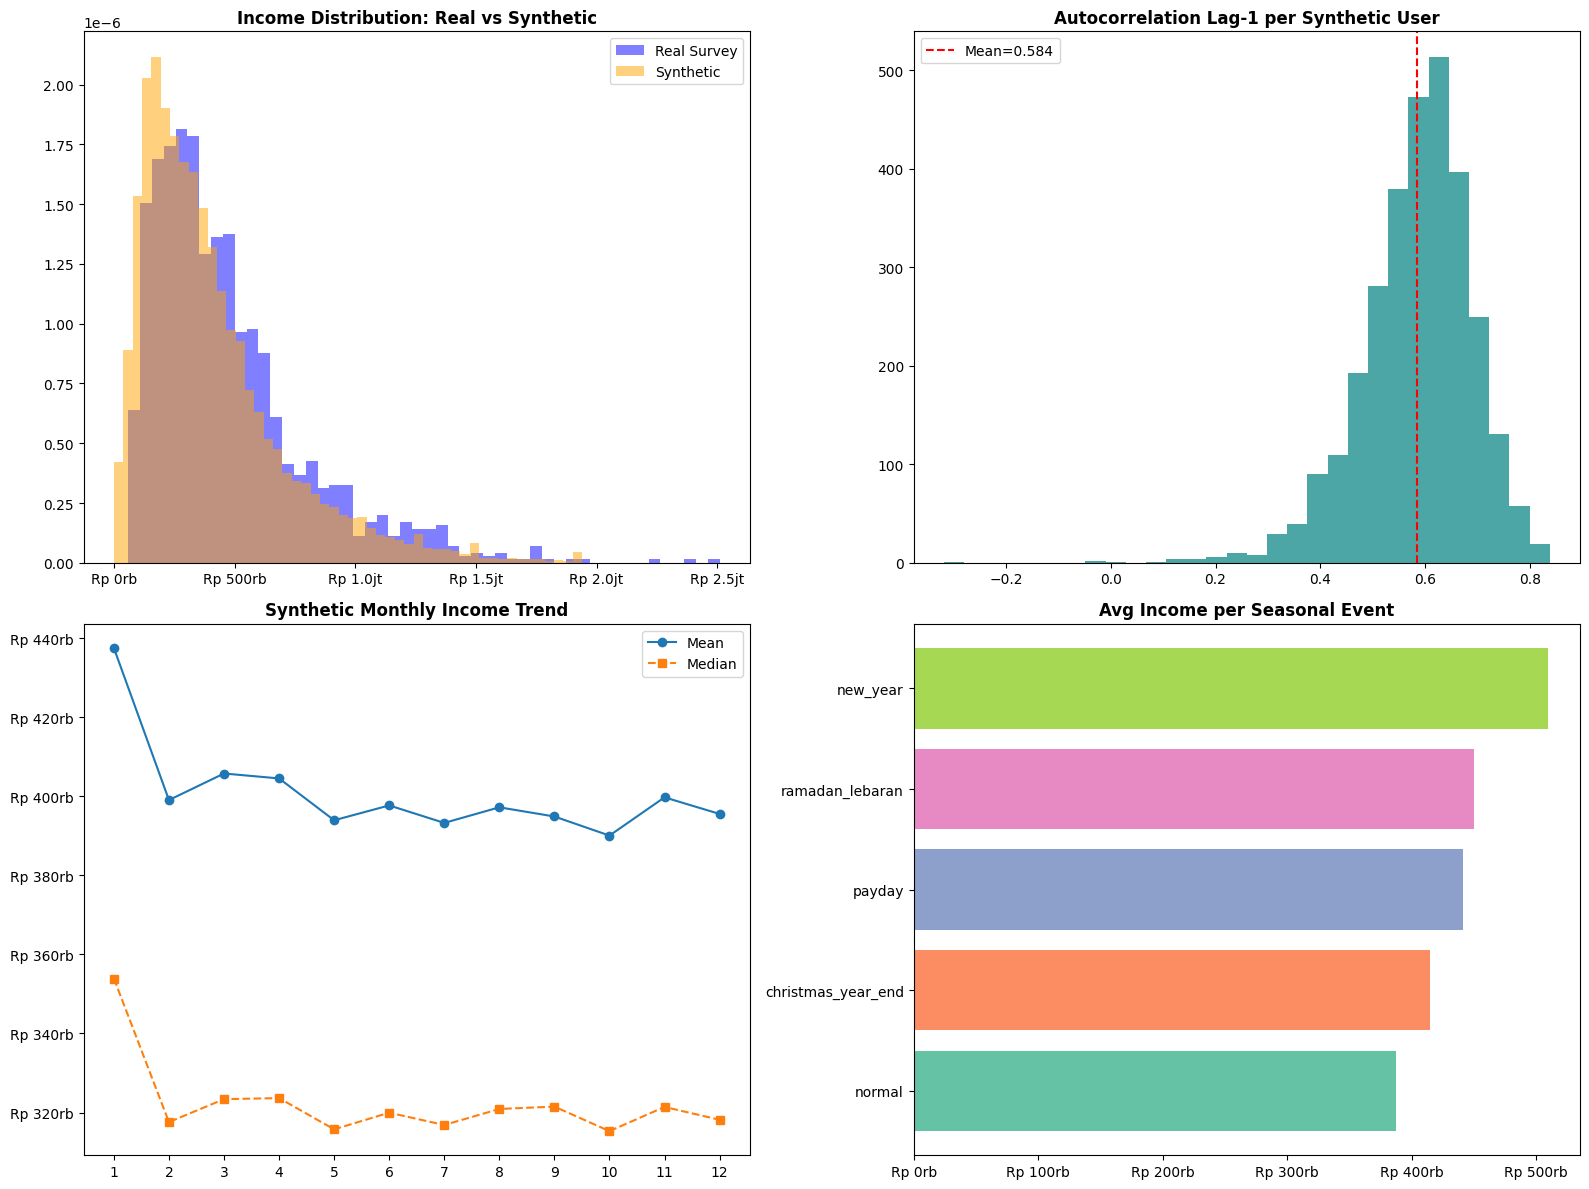


Disimpan: outputs/reports/bias_validation_report.md
Disimpan: outputs/charts/bias_validation_charts.png


In [10]:
# CELL 07.10 — Validation chart + report
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribution comparison
axes[0, 0].hist(real_inc, bins=50, alpha=0.5, label='Real Survey', density=True, color='blue')
axes[0, 0].hist(synth_inc, bins=50, alpha=0.5, label='Synthetic', density=True, color='orange')
axes[0, 0].set_title('Income Distribution: Real vs Synthetic', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].xaxis.set_major_formatter(IDR_FMT)

# Autocorrelation distribution
axes[0, 1].hist(autocorr_vals, bins=30, color='teal', alpha=0.7)
axes[0, 1].axvline(mean_ac, color='red', linestyle='--', label=f'Mean={mean_ac:.3f}')
axes[0, 1].set_title('Autocorrelation Lag-1 per Synthetic User', fontweight='bold')
axes[0, 1].legend()

# Monthly trend
mt = df_synth_raw.groupby('month')['synthetic_weekly_income'].agg(['mean', 'median'])
axes[1, 0].plot(mt.index, mt['mean'], 'o-', label='Mean')
axes[1, 0].plot(mt.index, mt['median'], 's--', label='Median')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_title('Synthetic Monthly Income Trend', fontweight='bold')
axes[1, 0].yaxis.set_major_formatter(IDR_FMT)
axes[1, 0].legend()

# Income per seasonal event
ei = df_synth_raw.groupby('seasonal_event_type')['synthetic_weekly_income'].mean().sort_values()
axes[1, 1].barh(ei.index, ei.values, color=sns.color_palette('Set2', len(ei)))
axes[1, 1].set_title('Avg Income per Seasonal Event', fontweight='bold')
axes[1, 1].xaxis.set_major_formatter(IDR_FMT)

plt.tight_layout()
safe_savefig('outputs/charts/bias_validation_charts.png')
plt.show()

report_lines = [
    "# Bias Validation Report — Fingo Income Predictor",
    "",
    "## Test Results",
    f"1. **Mean vs BPS**: ratio synthetic/BPS = {ratio_synth:.2f} ({'PASS' if test1_pass else 'FAIL'})",
    f"2. **Distribution (KS)**: stat={stat:.4f}, p={p_value:.4f} (toleransi: synthetic 52w vs real 4w snapshot)",
    f"3. **Seasonal direction**: Ramadan > Normal = {'PASS' if test3_pass else 'FAIL'}",
    f"4. **Autocorrelation lag-1**: {mean_ac:.4f} ({'PASS' if test4_pass else 'FAIL'}, expected 0.30-0.90)",
    "5. **BPS range per domisili**: lihat `outputs/reports/bps_range_validation.csv`",
    "6. **Income per gig_type**: lihat `outputs/reports/gig_type_income_validation.csv`",
    "",
    "## Catatan",
    "- Survey real 384 resp = acuan distribusi, bukan training utama.",
    "- Synthetic 3000 users = dataset training utama.",
    "- income_w4 (terlama) → income_w1 (terbaru) = urutan kronologis benar.",
    "- Perbedaan distribusi KS bisa muncul karena survey hanya snapshot 4 minggu, sedangkan synthetic adalah 52 minggu longitudinal.",
]

ensure_dir('outputs/reports/')

with open('outputs/reports/bias_validation_report.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print('\nDisimpan: outputs/reports/bias_validation_report.md')
print('Disimpan: outputs/charts/bias_validation_charts.png')


In [11]:
# CELL 07.11 — Final validation summary
print('=== Bias Validation Final Summary ===')
print(f'Test 1 Mean vs BPS: {"PASS" if test1_pass else "FAIL"}')
print(f'Test 2 KS statistic: {stat:.4f}, p-value: {p_value:.4f}')
print(f'Test 3 Seasonal direction: {"PASS" if test3_pass else "REVIEW"}')
print(f'Test 4 Autocorrelation: {"PASS" if test4_pass else "FAIL"}')
print(f'Test 5 BPS range output: outputs/reports/bps_range_validation.csv')
print(f'Test 6 Gig type validation output: outputs/reports/gig_type_income_validation.csv')
print('\nMain report: outputs/reports/bias_validation_report.md')


=== Bias Validation Final Summary ===
Test 1 Mean vs BPS: FAIL
Test 2 KS statistic: 0.1334, p-value: 0.0000
Test 3 Seasonal direction: PASS
Test 4 Autocorrelation: PASS
Test 5 BPS range output: outputs/reports/bps_range_validation.csv
Test 6 Gig type validation output: outputs/reports/gig_type_income_validation.csv

Main report: outputs/reports/bias_validation_report.md


In [12]:
# GIT PUSH — Commit dan push output notebook ini ke GitHub
import os, subprocess

LOCAL_DIR   = "/content/fingo-income-analysis"
BRANCH_NAME = "feat/income-predictor-final"
NOTEBOOK_NAME = "07_Bias_Validation.ipynb"

os.chdir(LOCAL_DIR)

def run_cmd(cmd, check=True):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    print(f"$ {cmd}")
    if r.stdout.strip(): print(r.stdout.strip())
    if r.stderr.strip(): print(r.stderr.strip())
    if check and r.returncode != 0:
        raise RuntimeError(f"Command gagal: {cmd}")
    return r

run_cmd('git config user.email "adelineclarisya@gmail.com"')
run_cmd('git config user.name "ClarisyaA"')

print("\n[1] Cek status")
run_cmd("git status --short", check=False)

print("\n[2] Add semua perubahan output")
run_cmd("git add data/ outputs/ notebooks/ *.ipynb", check=False)

print("\n[3] Commit")
commit_result = run_cmd(
    f'git commit -m "feat(DS2): output dari {NOTEBOOK_NAME}"',
    check=False
)
if commit_result.returncode != 0:
    print("[INFO] Tidak ada perubahan baru, skip commit.")

print("\n[4] Fetch remote terbaru")
run_cmd("git fetch origin")

print("\n[5] Rebase lalu push")
run_cmd(f"git pull --rebase origin {BRANCH_NAME}")
run_cmd(f"git push -u origin {BRANCH_NAME}")

print("\nPush berhasil!")


$ git config user.email "adelineclarisya@gmail.com"
$ git config user.name "ClarisyaA"

[1] Cek status
$ git status --short
?? outputs/charts/bias_validation_charts.png
?? outputs/reports/bias_validation_report.md
?? outputs/reports/bps_range_validation.csv
?? outputs/reports/gig_type_income_validation.csv

[2] Add semua perubahan output
$ git add data/ outputs/ notebooks/ *.ipynb

[3] Commit
$ git commit -m "feat(DS2): output dari 07_Bias_Validation.ipynb"
[feat/income-predictor-final 30dd98a] feat(DS2): output dari 07_Bias_Validation.ipynb
 4 files changed, 34 insertions(+)
 create mode 100644 outputs/charts/bias_validation_charts.png
 create mode 100644 outputs/reports/bias_validation_report.md
 create mode 100644 outputs/reports/bps_range_validation.csv
 create mode 100644 outputs/reports/gig_type_income_validation.csv

[4] Fetch remote terbaru
$ git fetch origin

[5] Rebase lalu push
$ git pull --rebase origin feat/income-predictor-final
Current branch feat/income-predictor-final 